Import relevant libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
from bokeh.palettes import Viridis5

**Translation of the example from the lecture notes**

In [2]:
# Problem parameters 
gamma = 5 # Risk aversion
beta = 0.95 # Discount factor
T=5 # Number of periods
r = 0.015 # riskless rate

# Wealth grid
maxw = np. log(50)
minw = np. log(1)
nw = 50 # Number of grid points
gw = np.linspace(minw, maxw, nw) # Log wealth grid
egw = np.exp(gw) # Wealth grid in levels

# Discretization of control
nc = 25 # Number of grid points for consumption
c = np.zeros((nw, T)) # Consumption
v = np.zeros((nw, T)) # Value function

# Risky asset parameters 
mu  = 0.065 # Equity risk premium
sig = 0.18 # Standard deviation of equity returns

# Quadrature
gret = np.array([
    r+mu - np.sqrt(3)*sig,
    r+mu,
    r+mu + np.sqrt(3)*sig
])
weights = np.array([1/6, 2/3, 1/6])

# Terminal period: the agent consumes all wealth
c[:, -1] = egw
v[:, -1] = (c[:, -1]**(1 - gamma)) / (1 - gamma)

# Backward induction
for t in range(T - 2, -1, -1):

    print(f"Period {t}")

    # Build an interpolating function for the value function at t+1
    v_func = CubicSpline(gw, v[:, t + 1])

    # Loop over wealth grid
    for iw, w in enumerate(egw):

        # Feasible consumption grid
        gc = np.linspace(0.001, 0.999*w, nc)

        # Savings
        sav = np.maximum(w - gc, 1e-4)

        # Initialize the expected continuation value
        ev = np.zeros(nc)

        # Expected returns for each quadrature point
        for qp in range(3):

            # Next-period wealth 
            w_t1 = np.log((1 + gret[qp])*sav)

            # Clip within grid bounds for interpolation
            w_t1 = np.clip(w_t1, minw, maxw)

            # Cubic spline interpolation of next-period value function
            ev += weights[qp] * v_func(w_t1)

        # Current-period utility
        u = (gc**(1 - gamma)) / (1 - gamma)

        # Right-hand side of Bellman equation
        rhs = u + beta * ev

        # Choose the maximizer
        jmax = np.argmax(rhs)
        v[iw, t] = rhs[jmax]
        c[iw, t] = gc[jmax]

Period 3
Period 2
Period 1
Period 0


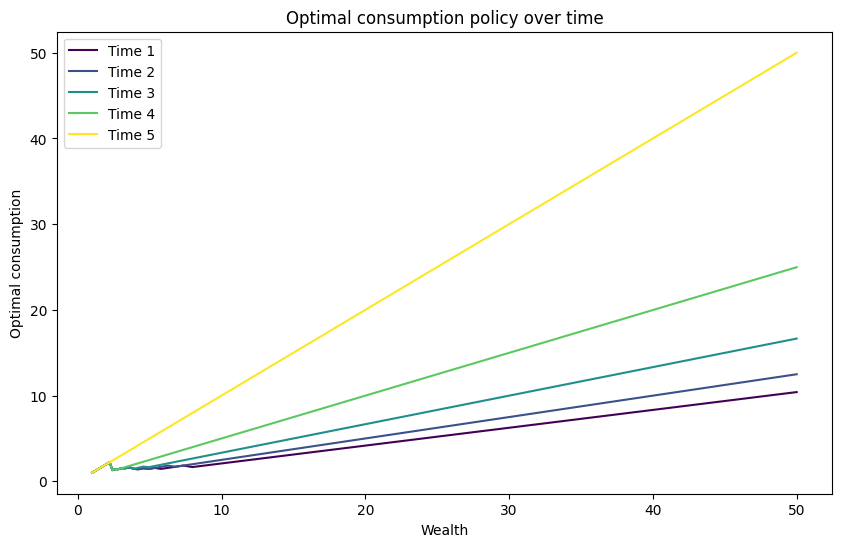

In [3]:
# Plot consumption policy at different times
plt.figure(figsize=(10, 6))

for t in range(T):
    plt.plot(egw, c[:, t], label=f'Time {t+1}', color=Viridis5[t])

plt.xlabel('Wealth')
plt.ylabel('Optimal consumption')
plt.title('Optimal consumption policy over time')
plt.legend()
plt.show()


**Problem 4a**

In [4]:
# Problem parameters 
gamma = 5 # Risk aversion
beta = 0.95 # Discount factor
T=5 # Number of periods
r = 0.015 # riskless rate

# Wealth grid
maxw = np.log(50)
minw = np.log(1)
nw = 50 # Number of grid points
gw = np.linspace(minw, maxw, nw) # Log wealth grid
egw = np.exp(gw) # Wealth grid in levels

# Discretization of control
nc = 25 # Number of grid points for consumption
na = 21 # Number of grid points for asset allocation
c = np.zeros((nw, T)) # Consumption
v = np.zeros((nw, T)) # Value function
a = np.zeros((nw, T)) # Asset allocation

# Risky asset parameters 
mu  = 0.065 # Equity risk premium
sig = 0.18 # Standard deviation of equity returns

# Quadrature
gret = np.array([
    r+mu - np.sqrt(3)*sig,
    r+mu,
    r+mu + np.sqrt(3)*sig
])
weights = np.array([1/6, 2/3, 1/6])

# Terminal period: the agent consumes all wealth
c[:, -1] = egw
v[:, -1] = (c[:, -1]**(1 - gamma)) / (1 - gamma)

# Backward induction
for t in range(T - 2, -1, -1):

    print(f"Period {t}")

    # Build an interpolating function for the value function at t+1
    v_func = CubicSpline(gw, v[:, t + 1])

    # Loop over wealth grid
    for iw, w in enumerate(egw):

        # Feasible consumption grid
        gc = np.linspace(0.001, 0.999*w, nc)

        # Savings
        sav = w - gc

        # Feasible asset allocation grid
        ga = np.linspace(0.0, 1.0, na)

        # Initialize the expected continuation value
        ev = np.zeros((nc, na))

        # Expected returns for each quadrature point
        for qp in range(3):

            # Next-period returns based on asset allocation
            ret = (1 - ga) * (1 + r) + ga * (1 + gret[qp])

            # Next-period wealth 
            w_t1 = np.log(np.outer(sav, ret))

            # Clip within grid bounds for interpolation
            w_t1 = np.clip(w_t1, minw, maxw)

            # Cubic spline interpolation of next-period value function
            ev += weights[qp] * v_func(w_t1)

        # Current-period utility
        u = (gc**(1 - gamma)) / (1 - gamma)

        # Right-hand side of Bellman equation
        rhs = u[:, None] + beta * ev
    
        # Choose the maximizer
        ic, ia = np.unravel_index(np.argmax(rhs), rhs.shape)
        v[iw, t] = rhs[ic, ia]
        c[iw, t] = gc[ic]
        a[iw, t] = ga[ia]


Period 3
Period 2
Period 1
Period 0


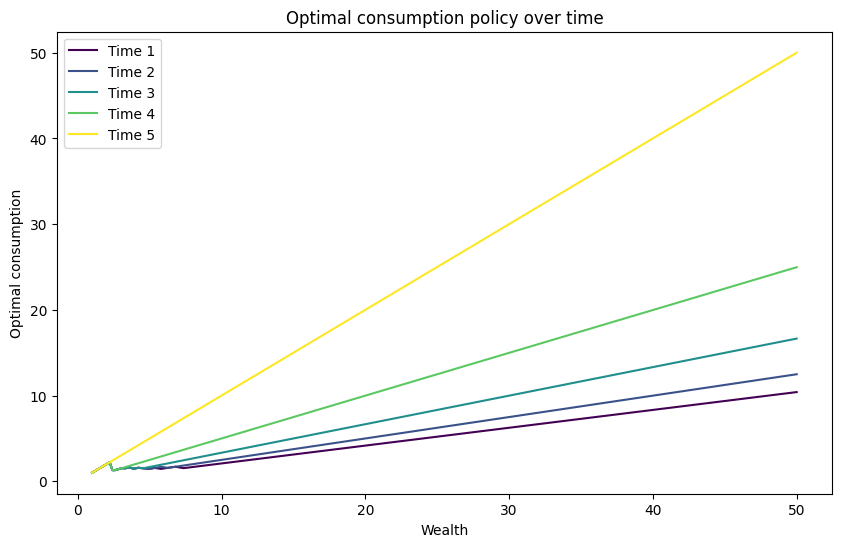

In [5]:
# Plot consumption policy at different times
plt.figure(figsize=(10, 6))

for t in range(T):
    plt.plot(egw, c[:, t], label=f'Time {t+1}', color=Viridis5[t])

plt.xlabel('Wealth')
plt.ylabel('Optimal consumption')
plt.title('Optimal consumption policy over time')
plt.legend()
plt.show()


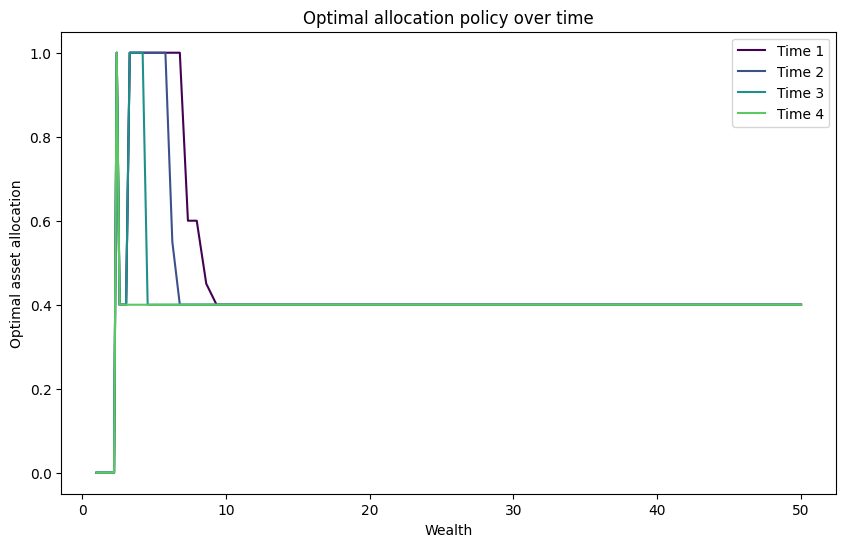

In [6]:
# Plot asset allocation policy at different times
plt.figure(figsize=(10, 6))

for t in range(T-1):
    plt.plot(egw, a[:, t], label=f'Time {t+1}', color=Viridis5[t])

plt.xlabel('Wealth')
plt.ylabel('Optimal asset allocation')
plt.title('Optimal allocation policy over time')
plt.legend()
plt.show()


**Problem 4b**

In [7]:
# Initial wealth
w0 = 10

# Simulate 10,000 returns over 5 periods
n_sim = 10000
r_sim = np.random.normal(loc=mu, scale=sig, size=(n_sim, T-1))

# Initialize arrays to store simulated consumption, asset allocation, and wealth
c_sim = np.zeros((n_sim, T))
a_sim = np.zeros((n_sim, T-1))
w_sim = np.zeros((n_sim, T+1))
w_sim[:, 0] = w0

# Precompute cubic spline interpolants for consumption and asset allocation policies
cs_c = [CubicSpline(gw, c[:, t], extrapolate=False) for t in range(T)]
cs_a = [CubicSpline(gw, a[:, t], extrapolate=False) for t in range(T-1)]

# Iterate over periods (excluding the last one)
for t in range(T-1):

    print(f"Period {t+1}")

    # Extract current wealth
    w_current = np.clip(np.log(w_sim[:, t]), minw, maxw)

    # Obtain the optimal consumption and asset allocation using interpolation
    c_sim[:, t] = np.clip(cs_c[t](w_current), 0.001, 0.999*w_sim[:, t])  
    a_sim[:, t] = np.clip(cs_a[t](w_current), 0.0, 1.0)

    # Update wealth for the next period
    gross_ret = a_sim[:, t] * (1 + r + r_sim[:, t]) + (1 - a_sim[:, t]) * (1 + r)
    w_sim[:, t+1] = np.maximum(gross_ret * (w_sim[:, t] - c_sim[:, t]), 1e-12)

# Last period consumption: consume all wealth 
c_sim[:, -1] = w_sim[:, T-1]

Period 1
Period 2
Period 3
Period 4


Plot simulated consumption, allocation, and wealth

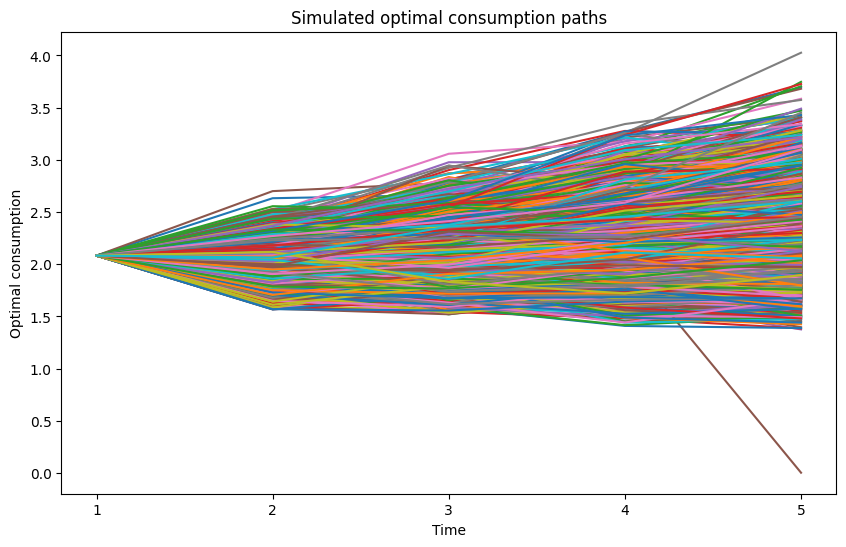

In [8]:
plt.figure(figsize=(10, 6))

for i in range(n_sim):
    plt.plot(range(1, T+1), c_sim[i, :])

plt.xlabel('Time')
plt.ylabel('Optimal consumption')
plt.title('Simulated optimal consumption paths')
plt.xticks(range(1, T+1))
plt.show()

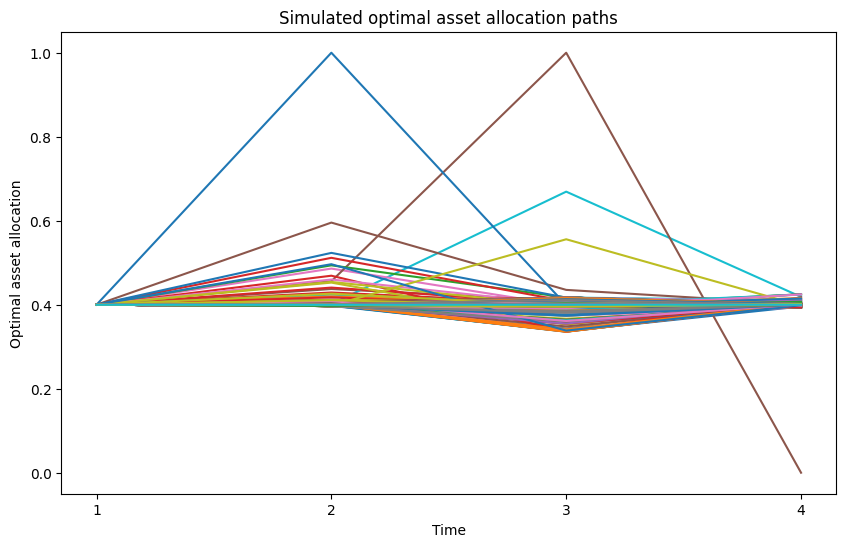

In [9]:
plt.figure(figsize=(10, 6))

for i in range(n_sim):
    plt.plot(range(1, T), a_sim[i, :])

plt.xlabel('Time')
plt.ylabel('Optimal asset allocation')
plt.title('Simulated optimal asset allocation paths')
plt.xticks(range(1, T))
plt.show()

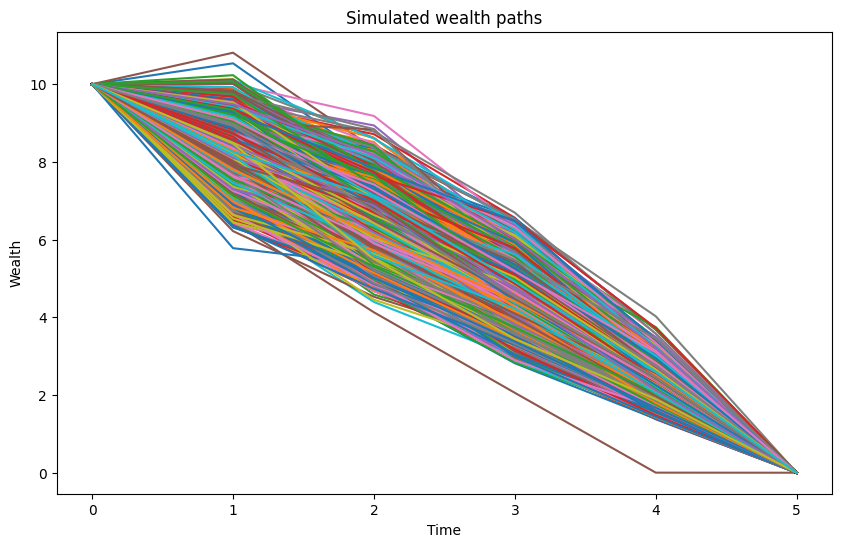

In [10]:
plt.figure(figsize=(10, 6))

for i in range(n_sim):
    plt.plot(range(T+1), w_sim[i, :])

plt.xlabel('Time')
plt.ylabel('Wealth')
plt.title('Simulated wealth paths')
plt.xticks(range(T+1))
plt.show()

Compute and plot the average consumption, asset allocation, and wealth in each period

In [11]:
# Compute the average consumption path
avg_c = pd.DataFrame(
    [['Consumption'] + np.mean(c_sim, axis=0).tolist()],
    columns=['var'] + [f't{i}' for i in range(1, T+1)]
)

# Compute the average asset allocation path
avg_a = pd.DataFrame(
    [['Asset Allocation'] + np.mean(a_sim, axis=0).tolist() + [0]],
    columns=['var'] + [f't{i}' for i in range(1, T+1)]
)

# Compute the average wealth path
avg_w = pd.DataFrame(
    [['Wealth'] + np.mean(w_sim, axis=0).tolist()],
    columns=['var'] + [f't{i}' for i in range(T+1)]
)

# Combine all averages into a single DataFrame
avg_paths = pd.concat([avg_c, avg_a, avg_w], ignore_index=True)
avg_paths = avg_paths[['var'] + [f't{i}' for i in range(T+1)]].copy()

# Fix number formatting
avg_paths_formatted = avg_paths.copy()
for col in [f't{i}' for i in range(T+1)]:
    avg_paths_formatted[col] = avg_paths_formatted[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else '')

avg_paths_formatted

,var,t0,t1,t2,t3,t4,t5
0,Consumption,,2.0822,2.0601,2.1452,2.2353,2.3295
1,Asset Allocation,,0.3999,0.4002,0.4001,0.4000,0.0000
2,Wealth,10.0000,8.2455,6.4399,4.4739,2.3295,0.0000


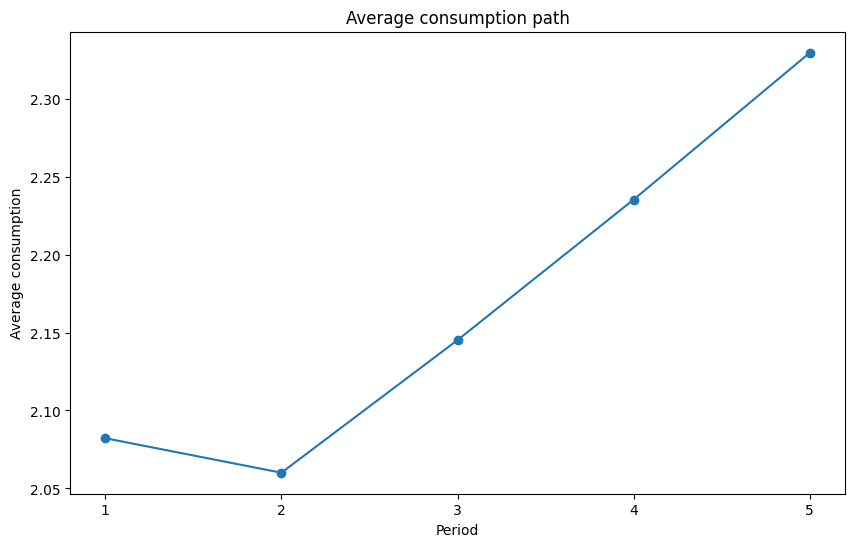

In [12]:
# Transpose the previous DataFrame
avg_paths_transposed = (avg_paths.T).reset_index()
avg_paths_transposed.columns = avg_paths_transposed.iloc[0]
avg_paths_transposed = avg_paths_transposed.drop(avg_paths_transposed.index[0]).reset_index(drop=True)
avg_paths_transposed.rename(columns={'var': 'Period'}, inplace=True)
avg_paths_transposed['Period'] = avg_paths_transposed['Period'].apply(lambda x: int(x[-1]))

# Plot the average consumption path
plt.figure(figsize=(10, 6))
plt.plot(
    avg_paths_transposed['Period'],
    avg_paths_transposed['Consumption'],
    marker='o',
    linestyle='-',
)
plt.xlabel('Period')
plt.ylabel('Average consumption')
plt.title('Average consumption path')
plt.xticks(range(1, T+1))
plt.show()


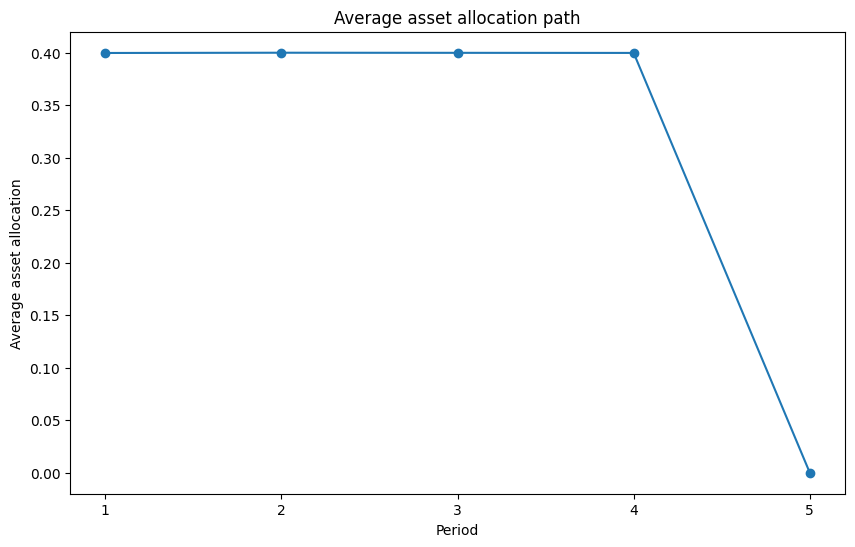

In [13]:
# Plot the average asset allocation path
plt.figure(figsize=(10, 6))
plt.plot(
    avg_paths_transposed['Period'],
    avg_paths_transposed['Asset Allocation'],
    marker='o',
    linestyle='-',
)
plt.xlabel('Period')
plt.ylabel('Average asset allocation')
plt.title('Average asset allocation path')
plt.xticks(range(1, T+1))
plt.show()

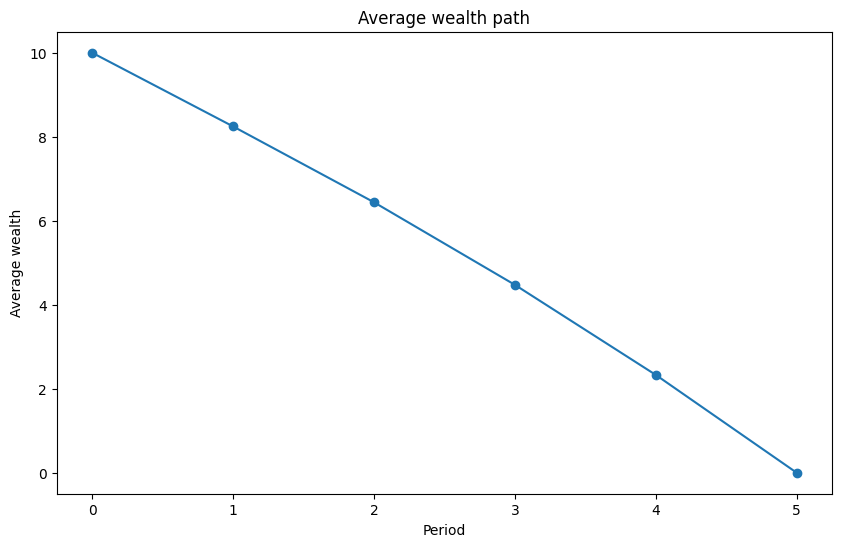

In [14]:
# Plot the average wealth path
plt.figure(figsize=(10, 6))
plt.plot(
    avg_paths_transposed['Period'],
    avg_paths_transposed['Wealth'],
    marker='o',
    linestyle='-',
)
plt.xlabel('Period')
plt.ylabel('Average wealth')
plt.title('Average wealth path')
plt.xticks(range(0, T+1))
plt.show()